In [110]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as phys
from IPython.display import display, Markdown

path2figures = 'C:/Users/paolo/Documents/S4_python_phys/PH461/TP2/figures/'
path2output = 'C:/Users/paolo/Documents/S4_python_phys/PH461/TP2/output/'
path2data = 'C:/Users/paolo/Documents/S4_python_phys/PH461/TP2/data/'

# Analyse de données

## Lecture des données

1. Charger dans deux tuples _x_ et _y_ les deux colonnes du fichier de données _coup_franc.txt_ du répertoire _data/_

In [111]:
# lecture des données
ligne = []
x = []
y = []
with open(path2data + "coup-franc.txt") as f :
    lignes = f.read()
lignes = lignes.split('\n')

for i in range(2, len(lignes)):
    ligne.append(lignes[i].replace(' ', '').split(','))
    
for k in range(len(ligne)):
    x.append(float(ligne[k][0]))
    y.append(float(ligne[k][1]))
print(x)
print(y)

[0.0, 2.05, 4.1, 6.15, 8.21, 10.26, 12.31, 14.36, 16.41, 18.46, 20.51, 22.56, 24.62, 26.67, 28.72, 30.77, 32.82, 34.87, 36.92, 38.97, 41.03, 43.08, 45.13, 47.18, 49.23, 51.28, 53.33, 55.38, 57.44]
[0.15, 1.19, 3.5, 4.44, 6.22, 7.02, 8.79, 9.48, 11.06, 10.91, 12.12, 13.44, 13.39, 14.46, 15.39, 15.18, 16.48, 14.76, 15.24, 15.19, 14.42, 13.13, 13.34, 11.56, 10.79, 10.4, 7.8, 4.45, 1.42]


2. Déterminer les coefficients du polynôme du deuxième degré $y(x) = c_2 x^2 + c_1 x^1 + c_0 x^0$ qui ajuste au mieux les données expérimentales.
Tracer les données et la parabole et commenter l'accord entre les données et le modèle de la parabole.

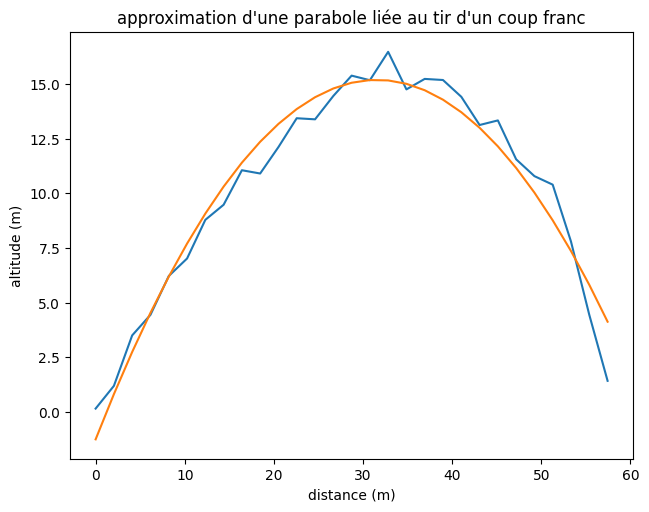

In [112]:
# ajustement des données

fig, ax = plt.subplots()
coeff = np.polyfit(x, y, 2)
poly = np.polyval(coeff, x)
ax.plot(x, y)
ax.plot(x, poly)
fig.tight_layout()
ax.set_title("approximation d'une parabole liée au tir d'un coup franc")
ax.set_ylabel('altitude (m)')
ax.set_xlabel('distance (m)')
plt.show ()

## Examen critique du modèle

3. Afficher les coefficients du polynôme obtenu à la question précédente dans le format suivant (en corrigeant les valeurs de l'exemple) :

In [113]:
modele = f'{round(coeff[0], 3)}x^2 + {round(coeff[1], 3)}x^1 + {round(coeff[2], 3)}x^0'

coefs_txt  = f'La parabole ajustant au mieux les données optimales s\'écrit\n\n$$\ny(x)= {modele}'



display (Markdown (coefs_txt))

La parabole ajustant au mieux les données optimales s'écrit

$$
y(x)= -0.017x^2 + 1.043x^1 + -1.258x^0

La parabole ajustant au mieux les données optimales s'écrit

$$
y(x)=-7.100x^2+3.401x^1-8.521x^0
$$

Dans le modèle, les coefficients du polynôme sont des fonctions des paramètres physiques $g$, $m$, $v_0$ et $\alpha$.

$$
y (x) = -\frac{gx^2}{2 v_0^2 \cos^2 \alpha} + x \tan \alpha
$$

Le terme constant obtenu par l'ajustement numérique prend une valeur finie tandis que le modèle prévoit qu'il soit nul. Pour autant, on ne rejettera pas le modèle sur cette base parce qu'il serait très difficile d'exclure la possibilité que cet écart soit une conséquence du bruit de mesure.

En pratique deux cas de figure peuvent se présenter :
- on ne dispose pas de plus de données $\Longrightarrow$ la modélisation n'apporte pas d'information
- on dispose d'un résultat expérimental supplémentaire $\Longrightarrow$ les prédictions du modèle peuvent être confrontées à ce résultat.

Pour la suite, on supposera que la valeur absolue de la vitesse initiale a été **mesurée par un moyen indépendant** qui a fourni le résultat suivant :

$$
v_0 = 30 \pm 4\,\mathrm {m/s}.
$$

L'angle $\alpha$ intervient dans le terme en $x$ (degré 1) qui s'exprime $c_1 = \tan \alpha$.

4. Calculer la valeur $\alpha$ correspondante.

In [114]:
alpha = 180/np.pi * np.arctan(coeff[1])
txt = f'D\'après le modèle, l\'angle initial est {alpha}'
display (Markdown (txt))

D'après le modèle, l'angle initial est 46.20325596539525

Dans le modèle, le coefficient en $x^2$ s'exprime $c_2 = -\frac{g}{2 v_0^2 \cos^2 \alpha} $.

5. En utilisant la valeur de  $\alpha$ obtenue par le terme d'ordre 1, la valeur absolue de la vitesse peut être déterminée par le coefficient $c_2$ :

$$
\begin{align}
\hat{v}_0 &= \sqrt{\frac{-g}{2 c_2}} \frac{1}{\cos \alpha} \\
    &= \sqrt{\frac{-g}{2 c_2}(1 + c_1^2)} 
\end{align}
$$

In [115]:
v0 = np.sqrt((-9.81/(2*coeff[0])) * (1 + coeff[1]**2))

txt = f'D\'après le modèle, la vitesse initiale est {v0}'
display (Markdown (txt))

D'après le modèle, la vitesse initiale est 24.89360688709388

## Calcul d'incertitude

On estime l'incertitude relative sur la vitesse ainsi obtenue par :

$$
\frac{\Delta \hat{v}_0}{\hat{v}_0} = \frac{1}{2} \frac{\Delta c_2}{c_2} + \frac{\Delta c_1}{c_1}
$$

L'incertitude sur les coefficients peut être estimée par l'écart-type des coefficients du polynôme qui sont retourné par la fonction `np.polyfit ()` avec l'argument d'entrée _cov = True_ : 
```python
coefs, cov = np.polyfit (x , y, 2, cov = True)
std = np.sqrt (np.diag (cov))
```

In [116]:
# Estimation de la vitesse initiale par l'ajustement quadratique
coefs, cov = np.polyfit (x , y, 2, cov = True)
std = np.sqrt (np.diag (cov))
print(std)

# estimation de l'incertitude à partir de l'erreur d'ajustement
delta_v0 = round(v0 * ((0.5 * (std[0]/coefs[0]) + (std[1]/coefs[1]))), 3)
txt = f'D\'après le modèle, la vitesse initiale est : {round(v0, 3)} ' + u'\u00B1' + f' {delta_v0} m/s'
display (Markdown (txt))

[0.00071006 0.04220861 0.52365016]


D'après le modèle, la vitesse initiale est : 24.894 ± 0.473 m/s

Le modèle fournit-il une valeur de cohérente ? 

Les deux valeurs de $\alpha$ fournies par le modèle ne sont pas compatibles entre elles. 
L'application du modèle conduit à une incohérence.

# Simulation du mouvement (lectures graphiques)

## Sans frottements

On considère le mouvement d'un ballon de masse $m = 0.45$ kg projeté avec une vitesse initiale $v_0$ et un angle $\alpha = 37\,^\circ$ par rapport à l'horizontale.
A l'état initial, le ballon est immobile sur le sol.

La deuxième loi de Newton s'applique :

$$
\left\{ \begin{array}{rcl}
m\ddot {x} &=& 0\\
m\ddot {y} &=& -mg
\end{array} \right.
$$

$$
\left\{ \begin{array}{rcl}
\dot {x} &=& v_0 \cos \alpha \\
\dot {y} &=& -gt + v_0 \sin \alpha
\end{array} \right.
$$

$$
\left\{ \begin{array}{rcl}
{x} &=& v_0 \cos \alpha \cdot t\\
{y} &=& -\dfrac{1}{2}gt^2 + v_0 \sin \alpha \cdot t
\end{array} \right.
$$

La trajectoire est obtenue par la substitution $t = \frac{x}{v_0 \cos \alpha}$ :

$$
y (x) = -\frac{gx^2}{2 v_0^2 \cos^2 \alpha} + x \tan \alpha
$$

In [117]:
# la définition de cette classe n'est pas indispensable.
# Elle illustre une utilisation possible des classes pour le stockage/affichage des paramètres d'une simulation
class Parameters:
    def __init__ (self, m, v0, alpha, k):
        self.m = m
        self.v0 = v0
        self.alpha = alpha
        self.k = k

    def __str__ (self):
        string  = f'Paramètres:\nmasse m = {self.m:.1f} kg\nvitesse initiale v0 = {self.v0:.1f} m/s\n'
        string += f'inclinaison de la vitesse initiale alpha = {self.alpha:.1f} deg.\n'
        string += f'coefficient de frottement k = {self.k:.2f} kg/s\n'
        return string

In [118]:
# paramètres physiques du mouvement
g = phys.value ('standard acceleration of gravity')
m = .45
v0 = 35
deg2rad = np.pi / 180
alpha = 37 * deg2rad

sans_f = Parameters (m, v0, alpha, 0)

1. Définir les fonctions _vx1_, _vy1_, _x1_ et _y1_ définissant les vitesses et positions à l'instant _t_ du mobile ainsi que la fonction _yx_ définissant la trajectoire $y (x)$.

In [119]:
def vx1 (t, v0, alpha, g = g):
    return v0 * np.cos(alpha)

def vy1 (t, v0, alpha, g = g):
    return -g*t + v0 * np.sin(alpha)

def x1 (t, v0, alpha, g = g):
    return v0 * np.cos(alpha) * t

def y1 (t, v0, alpha, g = g):
    return -g/2 * t**2 + v0 * np.sin(alpha) * t
    
def yx1 (x, v0, alpha, g = g):
    return -(g * x**2)/(2* (v0**2) * (np.cos(alpha))**2) + x * np.tan(alpha)

2. Tracer les vitesses instantanées $\dot{x}(t)$ et $\dot{y}(t)$ et lire sur le graphique l'instant où le mobile atteint le sommet de sa trajectoire.

_Indication_ : pour faciliter la lecture du graphique, on pourra utiliser la fonction `ax.axhline ()` (ou `ax.axvline ()`) pour tracer des lignes horizontales (ou verticales), suivant la syntaxe ci-dessous :
```python
ax.axhline (0, lw = 5, color = 'C0', alpha = .2) # trace une ligne horizontale d'équation y = 0
ax.axhline (2.15, ls = ':', alpha = .2) # trace une ligne verticale d'équation x = 2.15
```

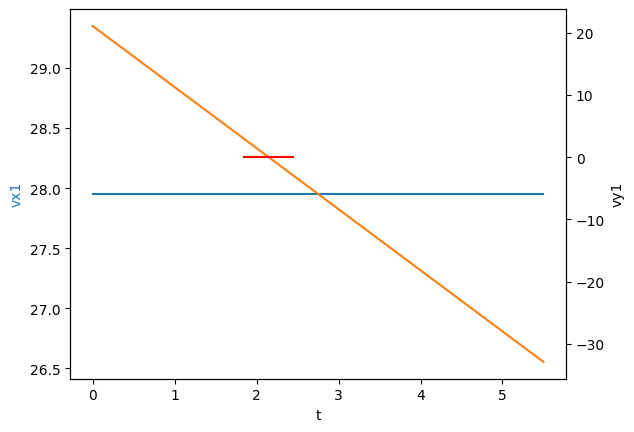

In [120]:
vxl = []
vyl = []
tmax = 5.5
t = np.linspace (0, tmax)

for i in range(0, len(t)):
    vxl += [vx1 (t[i], v0, alpha)]
    vyl += [vy1 (t[i], v0, alpha)]

fig, ax = plt.subplots ()
ax.plot(t, vxl, color = 'C0')
ax.set_ylabel ('vx1' , color = 'C0')

axT = ax.twinx ()
axT.plot(t ,vyl , color = 'C1')
axT.set_ylabel ('vy1')
ax.set_xlabel ('t')

axT.axhline (0, 0.35, 0.45, color = 'red') # trace une ligne horizontale d'équation y = 0

plt.show ()

3. Tracer les coordonnées instantanées $x (t)$ et $y(t)$ du mobile et lire sur le graphique la distance parcourue en vol.

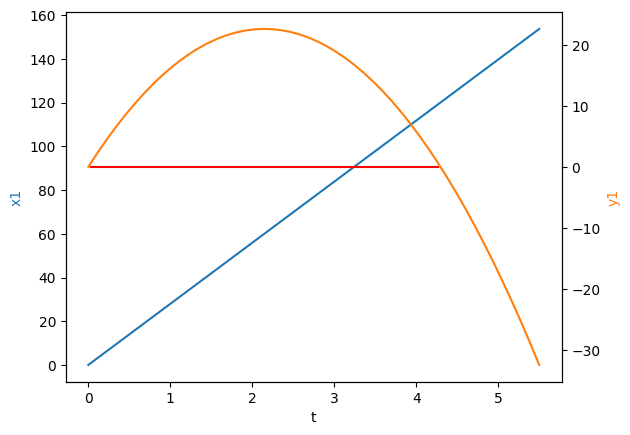

In [121]:
tmax = 5.5
t = np.linspace (0, tmax)
xl = []
yl = []

for i in range(0, len(t)):
    xl += [x1(t[i], v0, alpha)]
    yl += [y1(t[i], v0, alpha)]


fig, ax = plt.subplots ()
ax.plot (t ,xl , color = 'C0')
ax.set_ylabel ('x1', color = 'C0')
axT = ax.twinx ()
axT.plot (t ,yl , color = 'C1')
axT.set_ylabel ('y1' , color = 'C1')
ax.set_xlabel ('t')
axT.axhline (0, 0.05, 0.75, color = 'red') # trace une ligne horizontale d'équation y = 0

plt.show ()

4. Enregistrer les valeurs de $t$, $x$ et $y$ dans un fichier de 3 colonnes ayant l'entête suivante:

```
Simulation positions instantanées sans frottement
===================================================
Paramètres:
masse m = 0.5 kg
vitesse initiale v0 = 35.0 m/s
inclinaison de la vitesse initiale alpha = 0.6 deg.
coefficient de frottement k = 0.20 kg/s
```

Les colonnes s'afficheront dans le format suivant :

```
 temps (s),      x (m),      y (m)
     0.000,     0.0000,     0.0000
     0.112,     3.1375,     2.3025
```

In [122]:
# enregistrement des données
text2 = ' temps(s),     x(m),     y(m),\n'
text = """Simulation positions instantanées sans frottement
===================================================
Paramètres:
masse m = 0.5 kg
vitesse initiale v0 = 35.0 m/s
inclinaison de la vitesse initiale alpha = 0.6 deg.
coefficient de frottement k = 0.20 kg/s\n"""

for i in range(0, len(t)):
    text2 += f'{t[i]:{'>'}{'-'}{9}{'_'}.3f},' + f'{xl[i]:{'>'}{'-'}{9}{'_'}.3f},' + f'{yl[i]:{'>'}{'-'}{9}{'_'}.3f},' + '\n'

print(text2)
with open(path2output + 'Simulation positions instantanées sans frottement','w') as f :
    f.write (text + text2)

 temps(s),     x(m),     y(m),
    0.000,    0.000,    0.000,
    0.112,    3.137,    2.302,
    0.224,    6.275,    4.481,
    0.337,    9.412,    6.537,
    0.449,   12.550,    8.469,
    0.561,   15.687,   10.277,
    0.673,   18.825,   11.962,
    0.786,   21.962,   13.523,
    0.898,   25.100,   14.960,
    1.010,   28.237,   16.275,
    1.122,   31.375,   17.465,
    1.235,   34.512,   18.532,
    1.347,   37.650,   19.475,
    1.459,   40.787,   20.295,
    1.571,   43.925,   20.992,
    1.684,   47.062,   21.564,
    1.796,   50.200,   22.014,
    1.908,   53.337,   22.339,
    2.020,   56.475,   22.541,
    2.133,   59.612,   22.620,
    2.245,   62.750,   22.575,
    2.357,   65.887,   22.406,
    2.469,   69.025,   22.114,
    2.582,   72.162,   21.698,
    2.694,   75.300,   21.159,
    2.806,   78.437,   20.496,
    2.918,   81.575,   19.710,
    3.031,   84.712,   18.800,
    3.143,   87.850,   17.767,
    3.255,   90.987,   16.610,
    3.367,   94.125,   15.329,
    3.48

5. Représenter la trajectoire du mobile en traçant les positions instantanées  $y (t)$ et  $x (t)$ et superposer le résultat de la fonction `yx1 ()`.
   
_Indication_ : Il est recommandé d'utiliser l'instruction ```ax.set_aspect (1)``` de façon à ce que l'échelle des ordonnées et des abscisses soit les mêmes.

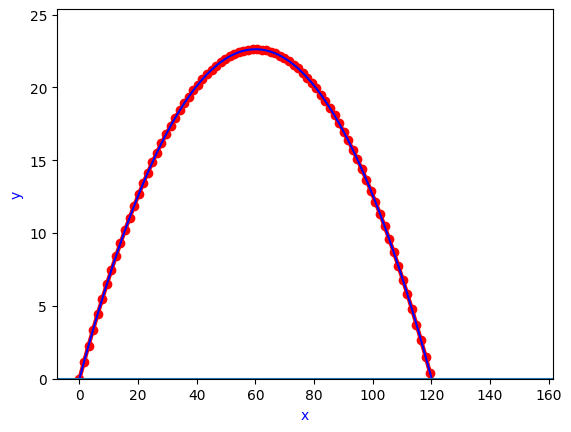

In [136]:
X1 = x1 (t, v0, alpha)
Y1 = y1 (t, v0, alpha)
YX1 = yx1 (X1, v0, alpha)
en_vol = np.where(Y1>=0)

fig, ax = plt.subplots ()
ax.plot (X1, Y1, color = 'red', lw = 3, marker = 'o')
ax.plot(X1, YX1, color = 'blue')
ax.set_xlabel ('x', color = 'blue')
ax.set_ylabel ('y', color = 'blue')
ax.axhline(0)
ax.set_ylim(bottom = 0)
plt.show ()

_Indication_ : on pourra utiliser la fonction `np.where ()` en s'inspirant de la syntaxe suivante :
```python
a = np.linspace (0, 1e-2, 11)
print (a)
print (np.where (a < 5e-3))
```

```
[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01 ]
(array([0, 1, 2, 3, 4]),)
```

## Simulation avec frottements

On reconsidère le mouvement précédent en y ajoutant maintenant la force de frottement fluide (simplifiée) $\vec{F} = -k\vec{v}$, avec $k = 0.2$ kg/s.

La deuxième loi de Newton s'applique :

$$
\left\{ \begin{array}{rcl}
m\ddot {x} &=& -k \dot {x}\\
m\ddot {y} &=& -mg - k \dot {y}
\end{array} \right.
$$

$$
\left\{ \begin{array}{rcl}
\dot {x} &=& v_0 \cos \alpha \cdot e^{-\frac{k}{m}t}\\
\dot {y} &=& \left( v_0 \sin \alpha +\frac{mg}{k} \right) e^{-\frac{k}{m}t} - \frac{mg}{k}\\
\end{array} \right.
$$

$$
\left\{ \begin{array}{rcl}
{x} &=& \frac{m}{k} v_0 \cos \alpha \left( 1 - e^{-\frac{k}{m}t} \right)\\
{y} &=& \frac{m}{k} \left( v_0 \sin \alpha +\frac{mg}{k} \right) \left( 1 - e^{-\frac{k}{m}t} \right)  - \frac{mg}{k} t\\
\end{array} \right.
$$

En exprimant $t$ en fonction de $x$ dans $x(t)$, il vient

$$
t = \frac{m}{k} \ln \left( \frac{mv_0 \cos \alpha}{mv_0 \cos \alpha - kx} \right)
$$

$$
y (x) = \left(  v_0 \sin \alpha + \frac{mg}{k} \right) \frac{x}{v_0 \cos \alpha} - \frac{m^2g}{k^2} \ln \left( \frac{mv_0 \cos \alpha}{mv_0 \cos \alpha - kx} \right)
$$

In [124]:
# paramètre physique du mouvement avec frottement
g = phys.value ('standard acceleration of gravity')
m = .45
v0 = 35
deg2rad = np.pi / 180
alpha = 37 * deg2rad
k = .2
avec_f = Parameters (m, v0, alpha, k)

2. Reprendre les 6 questions de la partie précédentes pour les nouvelles expressions cinématiques _vx2_, _vy2_, _x2_, et _y2_.

In [137]:
def x2 (t, m, v0, alpha, k, g = g):
    return m / k * v0 * np.cos (alpha) * (1 - np.exp (-k/m * t))

def y2 (t, m, v0, alpha, k, g = g):
    return m / k * (v0 * np.sin (alpha) + m * g / k) * (1 - np.exp (-k/m * t)) - m * g / k * t

def vx2 (t, m, v0, alpha, k, g = g):
    return v0 * np.cos (alpha) * np.exp (-k/m * t)
    
def vy2 (t, m, v0, alpha, k, g = g):
    return (v0 * np.sin (alpha) + m * g / k) * np.exp (-k/m * t) - m * g / k

def yx2 (x, m, v0, alpha, k, g = g):
    out = (v0 * np.sin(alpha) + (m * g)/k) * x/(v0 * np.cos(alpha)) - (m**2 * g)/k**2 * np.log((m * v0 * np.cos(alpha))/(m * v0 * np.cos(alpha) - k * x))
    return out

Vitesses instantanées et sommet de la trajectoire

NameError: name 'XXX' is not defined

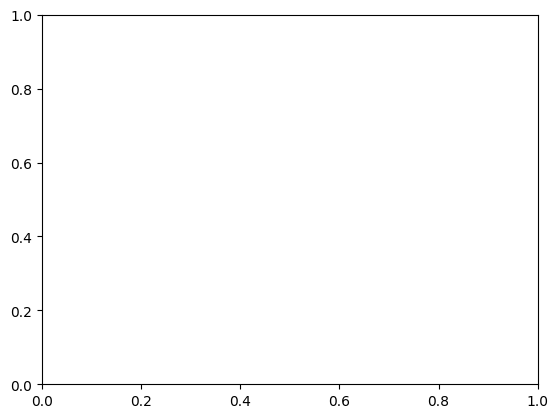

In [126]:
# vitesses instantanées et sommet de la trajectoire
tmax = 5.5
t = np.linspace (0, tmax, 100)

VY2 = vy2 (t, m, v0, alpha, k)

fig, ax = plt.subplots ()
ax.plot (XXX, XXX, color = 'C0')
ax.set_ylabel (XXX)
ax.plot (XXX, XXX, color = 'C1')
ax.set_xlabel (XXX)

ascension = np.where (XXX)
s = ascension [0][-1]

ax.legend ()

Equations horaires et distance de vol

In [ ]:
# Equations horaires et distance de vol
fig, ax = plt.subplots ()
ax.plot (XXX, XXX, color = 'C0')
ax.set_ylabel (XXX, color = 'C0')
axT = ax.twinx ()
axT.plot (XXX, color = 'C1')
axT.set_ylabel (XXX, color = 'C1')
ax.set_xlabel (XXX)

XXX


Trajectoire et vérification

In [ ]:
# Trajectoire et vérification
X2 = x2 (t, m, v0, alpha, k)
Y2 = y2 (t, m, v0, alpha, k)
en_vol = np.where (XXX)
fig, ax = plt.subplots ()
ax.plot (XXX, XXX)
ax.plot (XXX, XXX, ls = 'dashed')
ax.set_xlabel (XXX)
ax.set_ylabel (XXX)
ax.set_ylim ((0, 20))
ax.set_aspect (1)

Enregistrement des données

In [ ]:
# enregistrement des données
XXX

2. Tracer sur le même graphique les trajectoires avec et sans frottements.

In [ ]:
# display trajectories for both models



plt.show ()

# Variation de l'inclinaison de la vitesse initiale (lectures graphiques 2D)

On fait varier l'angle $\alpha$ uniformément entre 0 et 90 $^\circ$ par pas de 1 $^\circ$. 
Pour chaque valeur de $\alpha$ l'altitude $y$ est représentée sur une ligne en échelle de couleurs, en fonction du temps en abscisses.

Pour des raisons de lisibilité, on exclut les points où $y$ est négatif.
On remarquera pour cela que le projectile est en vol jusqu'à ce que son altitude s'annule, ce qui permet de réutiliser la fonction `np.where ()` pour localiser l'indice $s$ où le mobile attérrit :

```python
s = np.where (Y2 >= 0) [0][-1]
```

1. Lire sur la figure l'angle maximisant la portée du tir.
![variation_inclinaison](figures/variation_inclinaison.png)

2. Ajouter dans la boucle ```for``` du script les instructions permettant de tracer pour chaque valeur de $\alpha$ la portée du tir, c'est-à-dire la position $x$ atteinte au moment où $y$ s'annule (après son départ).

In [ ]:
# variation de l'inclinaison de la vitesse initiale
SHOWIMAGES = False
mat = ()
alpha_max = 90
tmax = 5.5
t = np.linspace (0, tmax, 100)
mat = np.zeros ((alpha_max, len (t)))
matx = np.zeros ((alpha_max, len (t)))
XXX
for a in range (alpha_max):
    alpha = a * deg2rad
    X2 = x2 (t, m, v0, alpha, k)
    Y2 = y2 (t, m, v0, alpha, k)
    for i in range (np.where (Y2 >= 0) [0][-1]):
        mat [a][i] = Y2 [i]
        matx [a][i] = X2 [i]
    XXX

if SHOWIMAGES:
    fig, axes = plt.subplots (ncols = 2, figsize = (12, 4))
    ax = axes [0]
    ax.set_xlabel ('t (s)')
    ax.set_ylabel ('angle initial (deg.)')
    im = ax.pcolor (t, [a for a in range (alpha_max)], mat)
    fig.colorbar (im, label = 'altitude max. (m)')
    ax = axes [1]
    ax.set_xlabel ('t (s)')
    ax.set_ylabel ('angle initial (deg.)')
    imx = ax.pcolor (t, [a for a in range (alpha_max)], matx)
    fig.colorbar (imx, label = 'portée du tir (m)')

fig, ax = plt.subplots ()
ax.plot (XXX)
ax.set_ylabel ('portée du tir (m)')
ax.set_xlabel ('angle initial (deg.)')
plt.show ()

# Variation de la force de frottement

L'angle de la vitesse initiale est à nouveau fixée à 37 $^\circ$ tandis qu'on considère $N=100$ valeurs du coefficient de frottement, uniformément réparties entre $k_\mathrm{min} = 1\cdot 10^{-3}$ et $k_\mathrm{max} = 2$ kg/s.

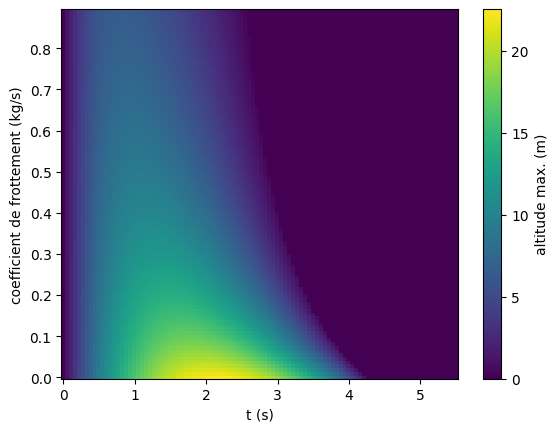

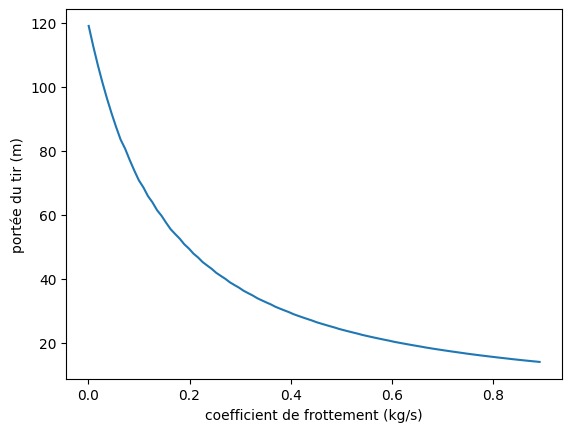

In [ ]:
# variation de l'inclinaison de la vitesse initiale
mat = ()
impacts = ()
N = 100
alpha = 37 * deg2rad
kmin, kmax = 1e-3, 0.9
mat = np.zeros ((N, len (t)))
tmax = 5.5
t = np.linspace (0, tmax, 100)
for j in range (N):
    k = kmin + (kmax - kmin)/N * j
    X2 = x2 (t, m, v0, alpha, k)
    Y2 = y2 (t, m, v0, alpha, k)   
    s = np.where (Y2 >= 0) [0][-1]
    for i in range (s):
        mat [j][i] = Y2 [i]
    impacts += X2 [np.where (Y2 >= 0) [0][-1]],
mat = np.array (mat)
fig, axes = plt.subplots (ncols = 2, figsize = (12, 4.2))
ax = axes [0]
im = ax.pcolor (t, [kmin + (kmax - kmin)/N * j for j in range (N)], mat)
ax.set_xlabel ('t (s)')
ax.set_ylabel ('coefficient de frottement (kg/s)')
fig.colorbar (im, label = 'altitude $y$ (m)')

ax = axes [1]
ax.plot ([kmin + (kmax - kmin)/N * j for j in range (N)], impacts)
ax.set_xlabel ('coefficient de frottement $k$ (kg/s)')
ax.set_ylabel ('portée $x$ du tir (m)')
k = .2 # juste au cas où...

1. Tracer la 20$^\mathrm{eme}$ et $(N-20)^\mathrm{eme}$ de la matrice _mat_.

In [ ]:

XXX

plt.show ()

On souhaite tracer les valeurs de $y$ représentées par l'image suivant la ligne joignant $k_1 = 0.1$ à $t=0$ et $k_2 = 0.5$ à $t=t_\mathrm{max}$ (pointillés blancs sur l'image ci-dessous).

![ligne_oblique](figures/ligne_oblique.png)

2. L'opération est déivisée en trois étapes :
    1. Écrire deux fonctions retournant :
        - l'indice de l'élément le plus proche d'une valeur donnée de $k_\mathrm{min} \le k \le k_\mathrm{max}$  dans la liste des coefficients de frottements en fonction de $k_\mathrm{min}$, $k_\mathrm{max}$ et $N$.
        - l'indice de l'élément le plus proche d'une valeur donnée de $0 \le t \le t_\mathrm{max}$  dans la liste des coefficients de frottements en fonction de $t_\mathrm{max}$ et $N_t$.
    2. Utiliser les fonctions précédentes pour ajouter à l'image le chemin de pixels joignant $k_1 = 0.1$ à $t=0$ et $k_2 = 0.5$ à $t=t_\mathrm{max}$.
    3. Stocker la valeur des pixels (_i.e._ élément de la matrice image) du chemin dans une liste nommée _profil_ et tracer ses $N_t$ valeurs en fonction du temps $t$ dans un graphique `ax.imshow ()`séparé.

In [ ]:
def index_of_k (k, kmin, kmax, N):
    

def index_of_t (t, tmax, N_t):
    
# test
#index_of_k (.88, kmin, kmax, N)
#index_of_t (0, tmax, N_t)

In [ ]:
# extraction d'une ligne arbitraire
mat = ()
N = 100
alpha = 37 * deg2rad
kmin, kmax = 1e-3, 2
mat = np.zeros ((N, len (t)))
tmax = 5.5
N_t = 100
t = np.linspace (0, tmax, N_t)
for j in range (N):
    k = kmin + (kmax - kmin)/N * j
    X2 = x2 (t, m, v0, alpha, k)
    Y2 = y2 (t, m, v0, alpha, k)
    #mat += Y2,    
    for i in range (np.where (Y2 >= 0) [0][-1]):
        mat [j][i] = Y2 [i]

fig, ax = plt.subplots ()
im = ax.imshow (mat, origin = 'lower')
#im = ax.pcolor (t, [kmin + (kmax - kmin)/N * j for j in range (N)], mat)
ax.set_xlabel ('t (s)')
ax.set_ylabel ('coefficient de frottement (kg/s)')
fig.colorbar (im, label = 'altitude (m)')

# Tracé de la ligne dans imshow
k1, k2 = .5, .1
a, b = (k2 - k1) / tmax, k1
ik = [index_of_k (k, kmin, kmax, N) for k in np.polyval ((a,b), t)]
ax.plot (t / tmax * N_t, ik, lw = 4, ls = ':', color = 'w')

# Tracé de la ligne en indices dans imshow

XXX

fig, ax = plt.subplots ()
ax.plot (t, profil)

In [ ]:
# profil de y suivant le chemin oblique 
k1, k2 = .5, .1

XXX
